In [21]:
# ── Imports ──
# Jackson Chourio V1 — logistic regression HR model
# Key notes:
#   - Age 22, youngest in roster, maximum Statcast fluctuation expected
#   - MLB debut March 2024 — 2 full seasons, thinner than Witt/Julio/Greene
#   - 20 HR / 20 SB in both seasons — confirmed multi-tool, responds to context
#   - American Family Field park_factor_hr = 90 — mild suppression
#   - pitcher_r retained — bats right
#   - k_per_9 retained — young hitter still developing approach vs pitch profiles
import sys
sys.path.append("../scripts")

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sqlalchemy import text
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score
from pybaseball import statcast_batter
from data_collection import engine


In [22]:
# ── Load base dataset from database ──
# Jackson Chourio player_id = 694192, team_id = 158 (Milwaukee Brewers)
PLAYER_ID = 694192

with engine.connect() as conn:
    df = pd.read_sql(text("""
        SELECT
            w.game_id,
            w.date,
            w.season,
            w.home_away,
            w.tb,
            w.hr,
            w.opponent_id,
            p.throws,
            p.era,
            p.k_per_9,
            pf.park_factor,
            pf.park_factor_hr
        FROM player_game_logs w
        JOIN pitcher_game_logs p ON w.game_id = p.game_id
        JOIN park_factors pf ON (
            CASE WHEN w.home_away = 'home' THEN 158
                 ELSE w.opponent_id
            END = pf.team_id
        )
        WHERE w.player_id = :pid
        ORDER BY w.date
    """), conn, params={"pid": PLAYER_ID})

print(f"Base dataset: {df.shape}")
print(df[['date', 'hr', 'tb', 'era']].head(10))


Base dataset: (279, 12)
         date  hr  tb   era
0  2024-03-29   0   1  4.20
1  2024-03-30   0   2  4.20
2  2024-03-31   0   3  4.20
3  2024-04-02   0   1  4.20
4  2024-04-03   1   4  4.20
5  2024-04-05   0   0  1.29
6  2024-04-06   1   4  7.20
7  2024-04-07   0   1  5.06
8  2024-04-08   0   1  3.00
9  2024-04-10   0   1  2.53


In [23]:
# ── HR distribution and base rate ──
print("HR distribution:")
print(df['hr'].value_counts().sort_index())

hr_rate = (df['hr'] >= 1).mean()
print(f"\nGames with 0 HR:  {(df['hr'] == 0).mean():.3f}")
print(f"Games with 1+ HR: {hr_rate:.3f} ({hr_rate*100:.1f}% of games)")
print(f"Games with 2+ HR: {(df['hr'] >= 2).mean():.3f}")

breakeven = -hr_rate / (1 - hr_rate) * 100
print(f"\nBreak-even American odds: {breakeven:.0f}")
print(f"\n(Witt: 16.0%, Julio: 17.4%, Greene: ~16.0% for comparison)
# Note: Chourio 21 HR in 148 games (2024), 21 HR in 131 games (2025)
# HR rate likely 14-16% — watch vs 16% threshold


SyntaxError: unterminated f-string literal (detected at line 12) (1965411258.py, line 12)

In [24]:
# ── Pull Statcast data via pybaseball ──
# Jackson Chourio player_id = 694192
# MLB debut March 2024 — pulling from 2024 start
print("Pulling Statcast data...")
statcast_raw = statcast_batter('2024-03-01', '2025-10-01', player_id=694192)
print(f"Statcast raw: {statcast_raw.shape}")


Pulling Statcast data...
Gathering Player Data
Statcast raw: (4631, 118)


In [25]:
# ── Aggregate Statcast to game level ──
batted = statcast_raw[statcast_raw['launch_speed'].notna()].copy()

# HR zone: 25-35 degree launch angle band — where balls most frequently leave the park
batted['in_hr_zone'] = batted['launch_angle'].between(25, 35).astype(int)

game_stats = batted.groupby('game_date').agg(
    avg_exit_velo=('launch_speed', 'mean'),
    barrel_count=('launch_speed_angle', lambda x: (x == 6).sum()),
    hard_hit_count=('launch_speed', lambda x: (x >= 95).sum()),
    hr_zone_count=('in_hr_zone', 'sum'),
    batted_balls=('launch_speed', 'count'),
).reset_index()

game_stats['barrel_rate']   = game_stats['barrel_count']   / game_stats['batted_balls']
game_stats['hard_hit_rate'] = game_stats['hard_hit_count'] / game_stats['batted_balls']
game_stats['hr_zone_rate']  = game_stats['hr_zone_count']  / game_stats['batted_balls']

print(f"Game-level Statcast: {game_stats.shape}")
print(game_stats[['game_date', 'barrel_rate', 'hr_zone_rate']].head(10))

Game-level Statcast: (284, 9)
    game_date  barrel_rate  hr_zone_rate
0  2024-03-03     0.000000      0.000000
1  2024-03-08     0.000000      0.142857
2  2024-03-09     0.000000      0.333333
3  2024-03-29     0.000000      0.000000
4  2024-03-30     0.000000      0.000000
5  2024-03-31     0.200000      0.400000
6  2024-04-02     0.000000      0.000000
7  2024-04-03     0.250000      0.000000
8  2024-04-05     0.000000      0.000000
9  2024-04-06     0.333333      0.333333


In [26]:
# ── Rolling Statcast features — 15-day window ──
game_stats = game_stats.sort_values('game_date').reset_index(drop=True)

game_stats['avg_exit_velo_15'] = game_stats['avg_exit_velo'].shift(1).rolling(15, min_periods=7).mean()
game_stats['barrel_rate_15']   = game_stats['barrel_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hard_hit_rate_15'] = game_stats['hard_hit_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hr_zone_rate_15']  = game_stats['hr_zone_rate'].shift(1).rolling(15, min_periods=7).mean()

print(game_stats[['game_date', 'barrel_rate_15', 'hr_zone_rate_15']].head(20))

     game_date  barrel_rate_15  hr_zone_rate_15
0   2024-03-03             NaN              NaN
1   2024-03-08             NaN              NaN
2   2024-03-09             NaN              NaN
3   2024-03-29             NaN              NaN
4   2024-03-30             NaN              NaN
5   2024-03-31             NaN              NaN
6   2024-04-02             NaN              NaN
7   2024-04-03        0.028571         0.125170
8   2024-04-05        0.056250         0.109524
9   2024-04-06        0.050000         0.097354
10  2024-04-07        0.078333         0.120952
11  2024-04-08        0.071212         0.155411
12  2024-04-10        0.065278         0.142460
13  2024-04-12        0.060256         0.131502
14  2024-04-13        0.055952         0.138592
15  2024-04-15        0.052222         0.140464
16  2024-04-16        0.052222         0.165464
17  2024-04-17        0.085556         0.222607
18  2024-04-19        0.085556         0.233718
19  2024-04-20        0.085556         0

In [27]:
# ── Merge Statcast into base dataset ──
game_stats['game_date'] = pd.to_datetime(game_stats['game_date'])
df['date'] = pd.to_datetime(df['date'])

df = df.merge(
    game_stats[['game_date', 'avg_exit_velo_15', 'barrel_rate_15',
                'hard_hit_rate_15', 'hr_zone_rate_15']],
    left_on='date',
    right_on='game_date',
    how='left'
)

print(f"After merge: {df.shape}")
print(df[['avg_exit_velo_15', 'barrel_rate_15', 'hr_zone_rate_15']].isnull().sum())

After merge: (279, 17)
avg_exit_velo_15    9
barrel_rate_15      9
hr_zone_rate_15     9
dtype: int64


In [28]:
# ── Feature engineering ──
df = df.sort_values('date').reset_index(drop=True)

df['is_home']   = (df['home_away'] == 'home').astype(int)
df['pitcher_r'] = (df['throws'] == 'R').astype(int)

# Chourio bats right — pitcher_r direction uncertain, let model decide
# American Family Field park_factor_hr = 90 — mild suppression
# is_home expected slightly negative, park_factor signal on road games in hitter parks

# Drop rows missing Statcast rolling features only
df_model = df.dropna(subset=['avg_exit_velo_15', 'barrel_rate_15',
                              'hr_zone_rate_15']).reset_index(drop=True)

print(f"Model dataset: {df_model.shape}")


Model dataset: (270, 19)


In [29]:
# ── Define features and binary target ──
# Chourio V1 — 9 features, same structure as Julio V2
# k_per_9 hypothesis: young hitter still developing approach —
#   high K/9 pitcher may suppress HR rate as Chourio learns pitch recognition
FEATURES = [
    # Chourio contact quality
    'avg_exit_velo_15',
    'barrel_rate_15',
    'hard_hit_rate_15',
    'hr_zone_rate_15',
    # Game context
    'is_home',
    'pitcher_r',
    # Pitcher
    'era',
    'k_per_9',
    # Park
    'park_factor',
]

X = df_model[FEATURES]
y_binary = (df_model['hr'] >= 1).astype(int)

print(f"Features: {len(FEATURES)}")
print(f"Dataset: {X.shape}")
print(f"HR rate: {y_binary.mean():.3f} ({y_binary.sum()} HR games out of {len(y_binary)})")
print(f"\n(Witt: 0.160, Julio: 0.174, Greene: ~0.160 for comparison)")
# Dataset smaller than core three — 2 seasons vs 3-4, expect higher CV variance


Features: 9
Dataset: (270, 9)
HR rate: 0.148 (40 HR games out of 270)

(Witt: 0.160, Julio: 0.174, Greene: ~0.160 for comparison)


In [30]:
# ── Scale features ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES)

In [31]:
# ── Baseline ──
baseline_acc = 1 - y_binary.mean()
print(f"Baseline accuracy (always predict no HR): {baseline_acc:.3f}")
breakeven = -y_binary.mean() / (1 - y_binary.mean()) * 100
print(f"Break-even odds for HR prop: {breakeven:.0f}")

Baseline accuracy (always predict no HR): 0.852
Break-even odds for HR prop: -17


In [32]:
# ── Regularization tuning — grid search over C ──
# C controls regularization strength
# Low C = stronger regularization = simpler model, less overfit
# High C = weaker regularization = fits training data more closely
C_grid = [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    LogisticRegression(max_iter=500),
    param_grid={'C': C_grid},
    cv=tscv,
    scoring='roc_auc',
    refit=True,
    n_jobs=-1
)

grid_search.fit(X_scaled, y_binary)

best_C   = grid_search.best_params_['C']
best_auc = grid_search.best_score_

print(f"Best C:        {best_C}")
print(f"Best CV AUC:   {best_auc:.3f}")
print()

results = pd.DataFrame(grid_search.cv_results_)
print(results[['param_C', 'mean_test_score', 'std_test_score']].round(4).to_string(index=False))

Best C:        0.001
Best CV AUC:   0.469

 param_C  mean_test_score  std_test_score
   0.001           0.4689          0.0792
   0.010           0.4652          0.0810
   0.050           0.4569          0.0871
   0.100           0.4488          0.0881
   0.250           0.4456          0.0964
   0.500           0.4500          0.1008
   1.000           0.4589          0.1051
   2.000           0.4652          0.1129
   5.000           0.4634          0.1140
  10.000           0.4598          0.1105


In [33]:
# ── Cross-validation with best C ──
model = grid_search.best_estimator_

cv_auc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='roc_auc')
cv_acc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='accuracy')

print(f"CV AUC per fold:  {[round(v,3) for v in cv_auc]}")
print(f"CV ACC per fold:  {[round(v,3) for v in cv_acc]}")
print(f"\nAUC mean +/- std: {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}")
print(f"ACC mean +/- std: {cv_acc.mean():.3f} +/- {cv_acc.std():.3f}")
print(f"\nBaseline ACC:     {baseline_acc:.3f}")
print(f"Improvement:      {cv_acc.mean() - baseline_acc:.3f}")
print(f"\nJulio V2 CV AUC: 0.566")
print(f"Chourio V1 CV AUC: {cv_auc.mean():.3f}")
print(f"Witt V10 CV AUC: 0.567")
print(f"\n(AUC > 0.55 = meaningful signal for sports betting)")


CV AUC per fold:  [np.float64(0.521), np.float64(0.497), np.float64(0.496), np.float64(0.312), np.float64(0.519)]
CV ACC per fold:  [np.float64(0.867), np.float64(0.822), np.float64(0.867), np.float64(0.844), np.float64(0.844)]

AUC mean +/- std: 0.469 +/- 0.079
ACC mean +/- std: 0.849 +/- 0.017

Baseline ACC:     0.852
Improvement:      -0.003

Julio V2 CV AUC: 0.566
Chourio V1 CV AUC: 0.469
Witt V10 CV AUC: 0.567

(AUC > 0.55 = meaningful signal for sports betting)


In [34]:
# ── Fit on full dataset ──
model.fit(X_scaled, y_binary)
df_model['p_hr'] = model.predict_proba(X_scaled)[:, 1]

insample_auc = roc_auc_score(y_binary, df_model['p_hr'])
insample_acc = accuracy_score(y_binary, model.predict(X_scaled))

print(f"In-sample AUC:  {insample_auc:.3f}")
print(f"In-sample ACC:  {insample_acc:.3f}")
print(f"CV AUC:         {cv_auc.mean():.3f}")
print(f"\nGap (in-sample - CV AUC): {insample_auc - cv_auc.mean():.3f}")
print("(smaller gap = less overfitting)")
print(f"\nMean P(HR):     {df_model['p_hr'].mean():.3f}")
print(f"Actual HR rate: {y_binary.mean():.3f}")

In-sample AUC:  0.609
In-sample ACC:  0.852
CV AUC:         0.469

Gap (in-sample - CV AUC): 0.140
(smaller gap = less overfitting)

Mean P(HR):     0.148
Actual HR rate: 0.148


In [35]:
# ── Calibration table ──
df_model['pred_bin'] = pd.qcut(df_model['p_hr'], q=5, labels=False)

calibration = df_model.groupby('pred_bin').agg(
    mean_predicted=('p_hr', 'mean'),
    actual_rate=('hr', lambda x: (x >= 1).mean()),
    n=('hr', 'count')
).round(3)

print(calibration)
spread = calibration['actual_rate'].iloc[-1] - calibration['actual_rate'].iloc[0]
print(f"\nSpread (bin 4 - bin 0): {spread:.3f}")
print(f"V6 spread:              0.185")
print(f"V5 spread:              ~0.12")
print("\n(larger spread = better discrimination between HR and non-HR games)")

          mean_predicted  actual_rate   n
pred_bin                                 
0                  0.146        0.130  54
1                  0.147        0.074  54
2                  0.148        0.093  54
3                  0.149        0.241  54
4                  0.150        0.204  54

Spread (bin 4 - bin 0): 0.074
V6 spread:              0.185
V5 spread:              ~0.12

(larger spread = better discrimination between HR and non-HR games)


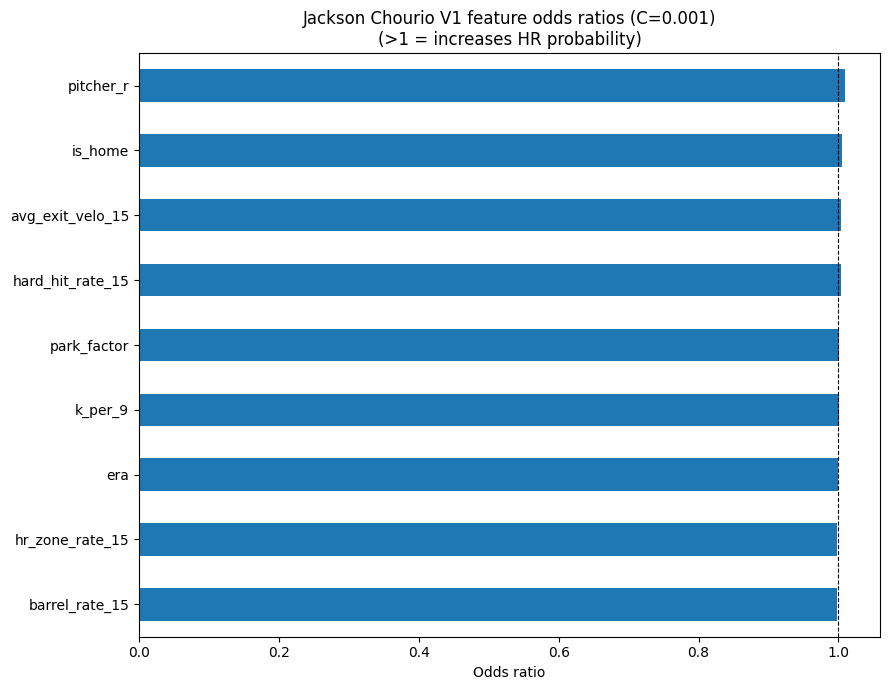


Odds ratios:
barrel_rate_15      0.999
hr_zone_rate_15     0.999
era                 1.000
k_per_9             1.001
park_factor         1.001
hard_hit_rate_15    1.004
avg_exit_velo_15    1.004
is_home             1.005
pitcher_r           1.009
dtype: float64


In [36]:
# ── Feature odds ratios ──
# Expected directions:
#   era        > 1 — higher ERA = worse pitcher = more HRs
#   k_per_9    < 1 — strikeout pitchers limit balls in play
#   park_factor > 1 — T-Mobile is 91, road games in hitter parks clearly better
#   pitcher_r  uncertain — Julio bats right
#   is_home    < 1 — T-Mobile suppresses HRs
coefs = pd.Series(model.coef_[0], index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
np.exp(coefs).sort_values().plot(kind='barh', ax=ax)
ax.axvline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(f'Jackson Chourio V1 feature odds ratios (C={best_C})\n(>1 = increases HR probability)')
ax.set_xlabel('Odds ratio')
plt.tight_layout()
plt.show()

print("\nOdds ratios:")
print(np.exp(coefs).round(3))


In [37]:
# ── Implied odds converter ──
def prob_to_american_odds(p):
    if p >= 0.5:
        return round(-p / (1 - p) * 100)
    else:
        return round((1 - p) / p * 100)

sample = df_model[['date', 'hr', 'p_hr']].copy()
sample['implied_odds'] = sample['p_hr'].apply(prob_to_american_odds)
sample['result'] = (sample['hr'] >= 1).map({True: '✅ HR', False: '❌ No HR'})

print("Last 20 games — model probability vs actual result:")
print(sample[['date', 'p_hr', 'implied_odds', 'result']].tail(20).to_string())

Last 20 games — model probability vs actual result:
          date      p_hr  implied_odds   result
250 2025-09-05  0.149213           570  ❌ No HR
251 2025-09-06  0.148927           571     ✅ HR
252 2025-09-08  0.146063           585  ❌ No HR
253 2025-09-09  0.148317           574  ❌ No HR
254 2025-09-10  0.148170           575     ✅ HR
255 2025-09-12  0.149691           568  ❌ No HR
256 2025-09-13  0.150002           567  ❌ No HR
257 2025-09-14  0.149458           569  ❌ No HR
258 2025-09-16  0.149899           567  ❌ No HR
259 2025-09-17  0.149508           569  ❌ No HR
260 2025-09-18  0.146646           582  ❌ No HR
261 2025-09-19  0.147740           577  ❌ No HR
262 2025-09-20  0.147468           578  ❌ No HR
263 2025-09-21  0.145115           589  ❌ No HR
264 2025-09-22  0.148150           575  ❌ No HR
265 2025-09-23  0.147829           576  ❌ No HR
266 2025-09-24  0.148648           573  ❌ No HR
267 2025-09-26  0.149332           570  ❌ No HR
268 2025-09-27  0.146834           5

In [38]:
# ── Save model artifacts ──
joblib.dump(model,  '../models/chourio_hr_logistic_v1_model.pkl')
joblib.dump(scaler, '../models/chourio_hr_logistic_v1_scaler.pkl')
print("Saved:")
print("  models/chourio_hr_logistic_v1_model.pkl")
print("  models/chourio_hr_logistic_v1_scaler.pkl")
print(f"\nBest C: {best_C}")
print(f"Features ({len(FEATURES)}): {FEATURES}")


Saved:
  models/chourio_hr_logistic_v1_model.pkl
  models/chourio_hr_logistic_v1_scaler.pkl

Best C: 0.001
Features (9): ['avg_exit_velo_15', 'barrel_rate_15', 'hard_hit_rate_15', 'hr_zone_rate_15', 'is_home', 'pitcher_r', 'era', 'k_per_9', 'park_factor']
